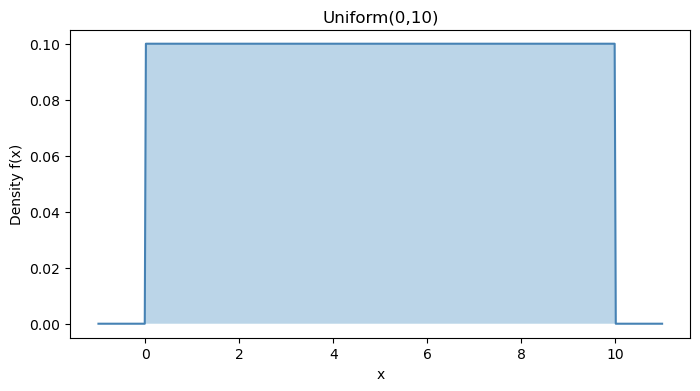

P(2 <= X <= 5) = 0.300


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Uniform distribution between a=0 and b=10
a, b = 0, 10
uniform_rv = stats.uniform(loc=a, scale=b-a)  # scipy uses loc=a, scale=(b-a)

x = np.linspace(-1, 11, 500)
pdf_values = uniform_rv.pdf(x)

plt.figure(figsize=(8,4))
plt.plot(x, pdf_values, color='steelblue')
plt.fill_between(x, pdf_values, alpha=0.3)
plt.xlabel('x')
plt.ylabel('Density f(x)')
plt.title(f'Uniform({a},{b})')
plt.show()

# Check: probability x falls between 2 and 5
prob = uniform_rv.cdf(5) - uniform_rv.cdf(2)
print(f"P(2 <= X <= 5) = {prob:.3f}")

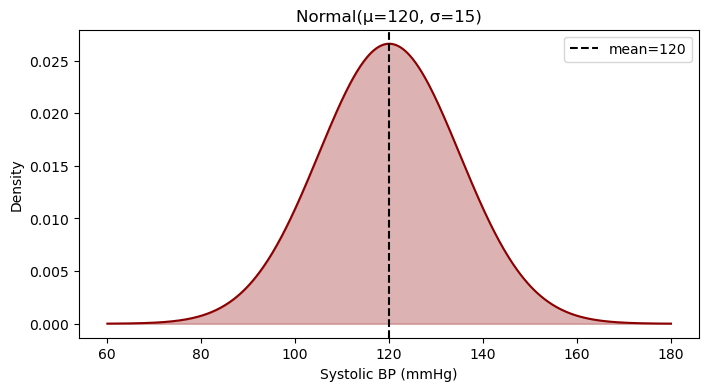

P(BP > 140) = 0.091
P(within 1 SD of mean) = 0.6827
P(within 2 SD of mean) = 0.9545
P(within 3 SD of mean) = 0.9973


In [2]:
# Normal distribution - e.g. modelling systolic blood pressure, mean=120, sd=15
mu, sigma = 120, 15
normal_rv = stats.norm(loc=mu, scale=sigma)

x = np.linspace(60, 180, 500)
pdf_values = normal_rv.pdf(x)

plt.figure(figsize=(8,4))
plt.plot(x, pdf_values, color='darkred')
plt.fill_between(x, pdf_values, alpha=0.3, color='darkred')
plt.axvline(mu, color='black', linestyle='--', label=f'mean={mu}')
plt.xlabel('Systolic BP (mmHg)')
plt.ylabel('Density')
plt.title(f'Normal(μ={mu}, σ={sigma})')
plt.legend()
plt.show()

# What proportion of patients have BP over 140 (hypertension threshold)?
prob_hypertensive = 1 - normal_rv.cdf(140)
print(f"P(BP > 140) = {prob_hypertensive:.3f}")

# The classic 68-95-99.7 rule - check it
for k in [1, 2, 3]:
    prob = normal_rv.cdf(mu + k*sigma) - normal_rv.cdf(mu - k*sigma)
    print(f"P(within {k} SD of mean) = {prob:.4f}")

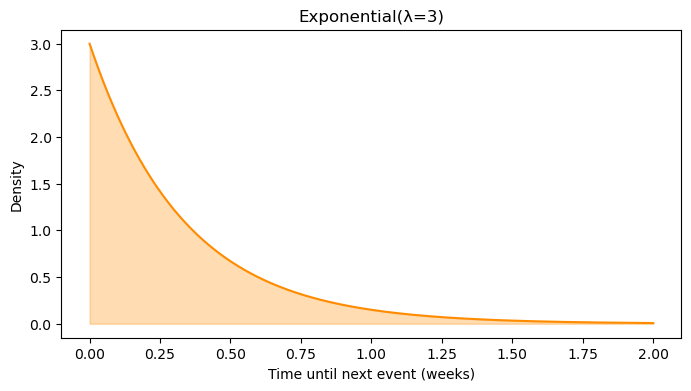

Mean time between events: 0.333 weeks
P(next event within 2 days, i.e. ~0.286 weeks): 0.576


In [3]:
# Exponential: time between sick-day call-ins, rate λ=3 per week -> mean time between = 1/3 week
lam = 3
exp_rv = stats.expon(scale=1/lam)  # scipy parameterises by scale=1/lambda

x = np.linspace(0, 2, 500)
pdf_values = exp_rv.pdf(x)

plt.figure(figsize=(8,4))
plt.plot(x, pdf_values, color='darkorange')
plt.fill_between(x, pdf_values, alpha=0.3, color='darkorange')
plt.xlabel('Time until next event (weeks)')
plt.ylabel('Density')
plt.title(f'Exponential(λ={lam})')
plt.show()

print(f"Mean time between events: {exp_rv.mean():.3f} weeks")
print(f"P(next event within 2 days, i.e. ~0.286 weeks): {exp_rv.cdf(2/7):.3f}")

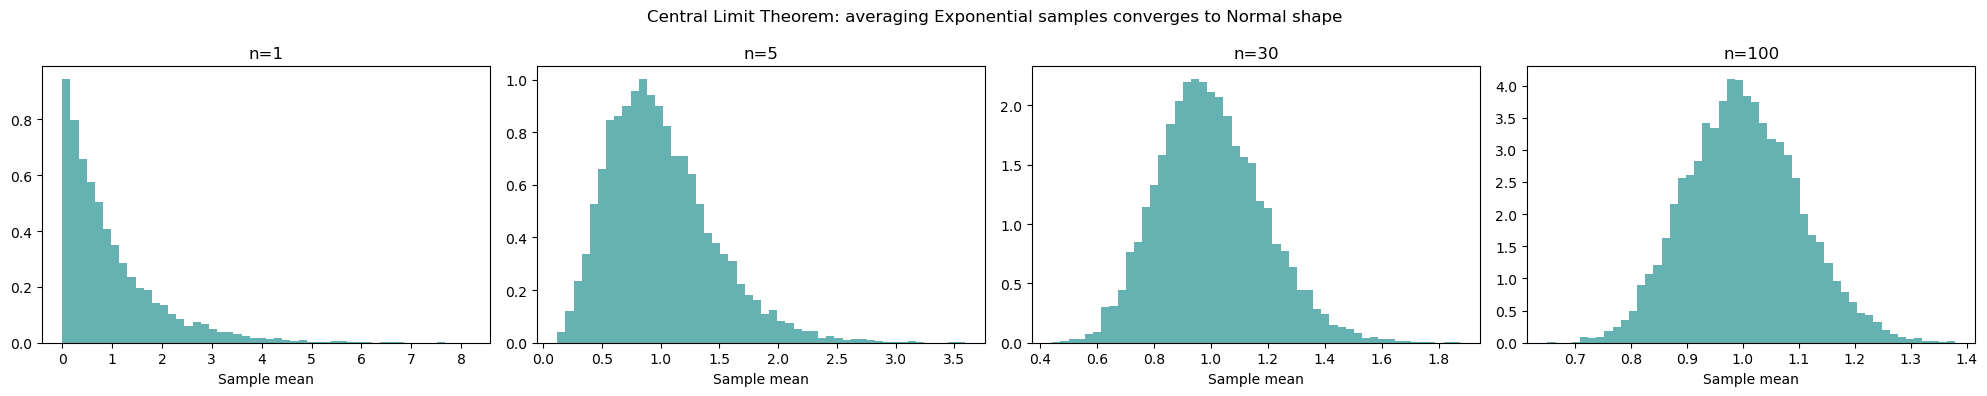

In [4]:
np.random.seed(42)

n_experiments = 10000
sample_sizes = [1, 5, 30, 100]

fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, n in zip(axes, sample_sizes):
    # For each of 10000 experiments, draw n samples from Exponential(λ=1) and take the mean
    sample_means = [np.mean(stats.expon.rvs(scale=1, size=n)) for _ in range(n_experiments)]
    
    ax.hist(sample_means, bins=50, density=True, alpha=0.6, color='teal')
    ax.set_title(f'n={n}')
    ax.set_xlabel('Sample mean')

plt.suptitle('Central Limit Theorem: averaging Exponential samples converges to Normal shape')
plt.tight_layout()
plt.show()
